In [83]:
import pandas as pd
import numpy as np

#Charger les données d'entraînement et de test
df_train = pd.read_csv("airbnb_train.csv")
df_test = pd.read_csv("airbnb_test.csv")

# Afficher les dimensions des ensembles d'entraînement et de test
print("train dimension:", df_train.shape)
print("test dimension:", df_test.shape)

# Afficher toutes les colonnes de l'ensemble d'entraînement
print("train set colomn: ")
print(df_train.columns.tolist())

# Afficher les premières lignes pour observer la structure des données
print(df_train.head())
print(df_train.info())


train dimension: (22234, 28)
test dimension: (51877, 27)
train set colomn: 
['id', 'log_price', 'property_type', 'room_type', 'amenities', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'description', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'host_since', 'instant_bookable', 'last_review', 'latitude', 'longitude', 'name', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms', 'beds']
         id  log_price property_type        room_type  \
0   5708593   4.317488         House     Private room   
1  14483613   4.007333         House     Private room   
2  10412649   7.090077     Apartment  Entire home/apt   
3  17954362   3.555348         House     Private room   
4   9969781   5.480639         House  Entire home/apt   

                                           amenities  accommodates  bathrooms  \
0  {TV,"Wireless Internet",Kitchen,"Free parking ...             3     

In [84]:
# Supprimer les lignes complètement dupliquées (s'il y en a)
df_train.drop_duplicates(inplace=True)

# Vérifier si la suppression a réussi (afficher à nouveau le nombre de lignes)
print("deduplication :", df_train.shape)

# pour garantir l’unicité du jeu de données, réduire le bruit, améliorer l’efficacité de l’apprentissage et augmenter la précision des prédictions.

deduplication : (22234, 28)


In [85]:
missing_info = df_train.isnull().mean()
missing_df = pd.DataFrame({
    'missing_count': df_train.isnull().sum(),
    'missing_percent': missing_info
}).sort_values(by='missing_percent', ascending=False)

# Afficher les colonnes avec des valeurs manquantes (vous pouvez aussi faire print(missing_df.head(10)) pour les premières colonnes)
print("Pourcentage de valeurs manquantes dans chaque colonne du jeu d'entraînement :")
print(missing_df)

# Définir un seuil : supprimer les colonnes avec un taux de valeurs manquantes > 20%
cols_to_drop = missing_df[missing_df['missing_count'] > 1000].index.tolist()
print("\nColonnes à supprimer : ", cols_to_drop)

# Supprimer ces colonnes (dans les ensembles d'entraînement et de test)
df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=[col for col in cols_to_drop if col in df_test.columns])

# Afficher les dimensions après suppression des colonnes avec trop de valeurs manquantes
print("train: ", df_train.shape)
print("test: ", df_test.shape)

#On supprime les colonnes avec trop de valeurs manquantes pour éviter les biais, simplifier le modèle, et s'assurer que seules les données fiables sont utilisées.

Pourcentage de valeurs manquantes dans chaque colonne du jeu d'entraînement :
                        missing_count  missing_percent
host_response_rate               5475         0.246244
review_scores_rating             4978         0.223891
first_review                     4725         0.212512
last_review                      4716         0.212108
neighbourhood                    2086         0.093820
zipcode                           303         0.013628
host_identity_verified             56         0.002519
host_since                         56         0.002519
host_has_profile_pic               56         0.002519
bathrooms                          51         0.002294
beds                               35         0.001574
bedrooms                           26         0.001169
description                         0         0.000000
longitude                           0         0.000000
property_type                       0         0.000000
room_type                           0     

In [86]:
# Colonnes de type object à conserver
keep_object_cols = [
    'property_type', 'room_type', 'bed_type', 'cancellation_policy',
    'city', 'amenities','host_has_profile_pic', 'host_identity_verified', 'instant_bookable']
#On Concerve ces colonnes de type object parce qu'elles contiennent des informationsproperty_type, room_type, `bbed_type ou `canc_cancellation_policy décrivent préccity caamenities renseigne sur le niveau d’équipement, ce qui est souvent corrhost_has_profile_pic,_host_identity_verified ou instant_bookable reflète

# Identifier les colonnes de type object à supprimer (celles qui ne sont pas dans la liste de conservation)
drop_obj = [col for col in df_train.select_dtypes(include='object').columns if col not in keep_object_cols]

# Supprimer ces colonnes
df_train.drop(columns=drop_obj, inplace=True)
df_test.drop(columns=[col for col in drop_obj if col in df_test.columns], inplace=True)

# Afficher les dimensions après suppression des colonnes de type object non utiles
print("train: ", df_train.shape)
print("test:", df_test.shape)

#Certaines colonnes object contiennent trop de valeurs différentes（par exemple，name，description）
#Pas de valeur explicative claire
#Simplification des données


train:  (22234, 19)
test: (51877, 18)


In [87]:
#On utilise la médiane pour remplir les valeurs manquantes car elle est robuste, simple, et permet de limiter l’impact des valeurs extrêmes sur le modèle.
num_cols = ['bathrooms', 'bedrooms', 'beds']
for col in num_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())
    df_test[col] = df_test[col].fillna(df_test[col].median())


In [88]:
# Créer une nouvelle colonne qui compte le nombre d'équipements (amenities) par logement
df_train['amenities_count'] = df_train['amenities'].apply(lambda x: len(str(x).split(',')))
df_test['amenities_count'] = df_test['amenities'].apply(lambda x: len(str(x).split(',')))

# Supprimer la colonne d'origine 'amenities' (liste de texte)
df_train.drop(columns=['amenities'], inplace=True)
df_test.drop(columns=['amenities'], inplace=True)

#On transforme amenities en amenities_count pour simplifier les données, extraire une information pertinente, et rendre la variable exploitable par les modèles de machine learning.


In [89]:
# Mapper les champs booléens
bool_map = {'t': True, 'f': False, 'True': True, 'False': False}

for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    df_train[col] = df_train[col].map(bool_map)
    # Remplacer les valeurs manquantes par False (ou True selon le besoin)
    df_train[col] = df_train[col].fillna(False)
    # Convertir en entier : True → 1, False → 0
    df_train[col] = df_train[col].astype(int)

# Pour 'cleaning_fee', on remplit les valeurs manquantes avec False puis on convertit en entier
df_train['cleaning_fee'] = df_train['cleaning_fee'].fillna(False).astype(int)

# Vérifier les résultats
print(df_train[['host_has_profile_pic', 'host_identity_verified', 'instant_bookable', 'cleaning_fee']].head())

#Ce code transforme les champs booléens du jeu de test en valeurs numériques exploitables par les modèles, en assurant une gestion propre des valeurs manquantes et un format cohérent.

   host_has_profile_pic  host_identity_verified  instant_bookable  \
0                     1                       0                 1   
1                     1                       1                 1   
2                     1                       0                 1   
3                     1                       1                 0   
4                     1                       1                 0   

   cleaning_fee  
0             0  
1             0  
2             0  
3             1  
4             1  


/var/folders/bk/lkr0l6cd3cn29q5v5089cz6c0000gn/T/ipykernel_1357/3545102124.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[col] = df_train[col].fillna(False)
/var/folders/bk/lkr0l6cd3cn29q5v5089cz6c0000gn/T/ipykernel_1357/3545102124.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[col] = df_train[col].fillna(False)


In [90]:
# Pour le set test
bool_map = {'t': True, 'f': False, 'True': True, 'False': False}

for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    df_test[col] = df_test[col].map(bool_map)
    df_test[col] = df_test[col].fillna(False)
    df_test[col] = df_test[col].astype(int)
df_test['cleaning_fee'] = df_test['cleaning_fee'].fillna(False).astype(int)


/var/folders/bk/lkr0l6cd3cn29q5v5089cz6c0000gn/T/ipykernel_1357/3956253792.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[col] = df_test[col].fillna(False)
/var/folders/bk/lkr0l6cd3cn29q5v5089cz6c0000gn/T/ipykernel_1357/3956253792.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[col] = df_test[col].fillna(False)


In [91]:
# Supprimer les logements qui ne peuvent pas accueillir de personnes (accommodates ≤ 0)
df_train = df_train[df_train['accommodates'] > 0]

# Supprimer les lignes où le nombre de lits, chambres ou salles de bain est nul
df_train = df_train[(df_train['beds'] > 0) & (df_train['bedrooms'] > 0) & (df_train['bathrooms'] > 0)]

# Vérification des coordonnées géographiques : conserver uniquement les valeurs valides de latitude et longitude
df_train = df_train[(df_train['latitude'].between(-90, 90)) & (df_train['longitude'].between(-180, 180))]

# Afficher les dimensions du jeu d'entraînement après nettoyage
print("train:", df_train.shape)

#Ces suppressions servent à nettoyer les anomalies, garantir la validité des données, et à s’assurer que les exemples utilisés pour l’apprentissage du modèle reflètent des logements réels et exploitables.

train: (20165, 19)


In [103]:
# Remplacer les valeurs invalides (≤ 0) par 1 pour les champs essentiels
df_test['accommodates'] = df_test['accommodates'].apply(lambda x: max(x, 1))
df_test['beds'] = df_test['beds'].apply(lambda x: max(x, 1))
df_test['bedrooms'] = df_test['bedrooms'].apply(lambda x: max(x, 1))
df_test['bathrooms'] = df_test['bathrooms'].apply(lambda x: max(x, 1))

# Corriger les latitudes et longitudes invalides en les remplaçant par la médiane
df_test['latitude'] = df_test['latitude'].apply(lambda x: x if -90 <= x <= 90 else df_test['latitude'].median())
df_test['longitude'] = df_test['longitude'].apply(lambda x: x if -180 <= x <= 180 else df_test['longitude'].median())

#Ici on ne peut pas supprimer les lignes du jeu de test, car chaque ligne correspond à une prédiction attendue.
#Ainsi, au lieu d’éliminer les logements avec des valeurs incohérentes ou extrêmes, on choisit de remplacer les valeurs anormales par des valeurs par défaut acceptables.


In [93]:
# Uniformiser les chaînes de caractères : suppression des espaces + mise en minuscules
string_fields = ['property_type', 'room_type', 'bed_type', 'cancellation_policy']
for col in string_fields:
    df_train[col] = df_train[col].str.strip().str.lower()

# Convertir en type catégoriel (économie de mémoire + préparation au one-hot encoding)
category_fields = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']
for col in category_fields:
    df_train[col] = df_train[col].astype('category')

# Vérification finale des types de colonnes
print(df_train.dtypes)

#Uniformise les chaînes de caractères pour éviter les doublons causés par les majuscules ou les espaces.
#Prépare les colonnes pour l'encodage en les convertissant au type category.
#Optimise l’utilisation de la mémoire et facilite les étapes de transformation comme le one-hot encoding.


id                           int64
log_price                  float64
property_type             category
room_type                 category
accommodates                 int64
bathrooms                  float64
bed_type                  category
cancellation_policy       category
cleaning_fee                 int64
city                      category
host_has_profile_pic         int64
host_identity_verified       int64
instant_bookable             int64
latitude                   float64
longitude                  float64
number_of_reviews            int64
bedrooms                   float64
beds                       float64
amenities_count              int64
dtype: object


In [94]:
#Pour le test
string_fields = ['property_type', 'room_type', 'bed_type', 'cancellation_policy']
for col in string_fields:
    df_test[col] = df_test[col].str.strip().str.lower()

category_fields = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']
for col in category_fields:
    df_test[col] = df_test[col].astype('category')


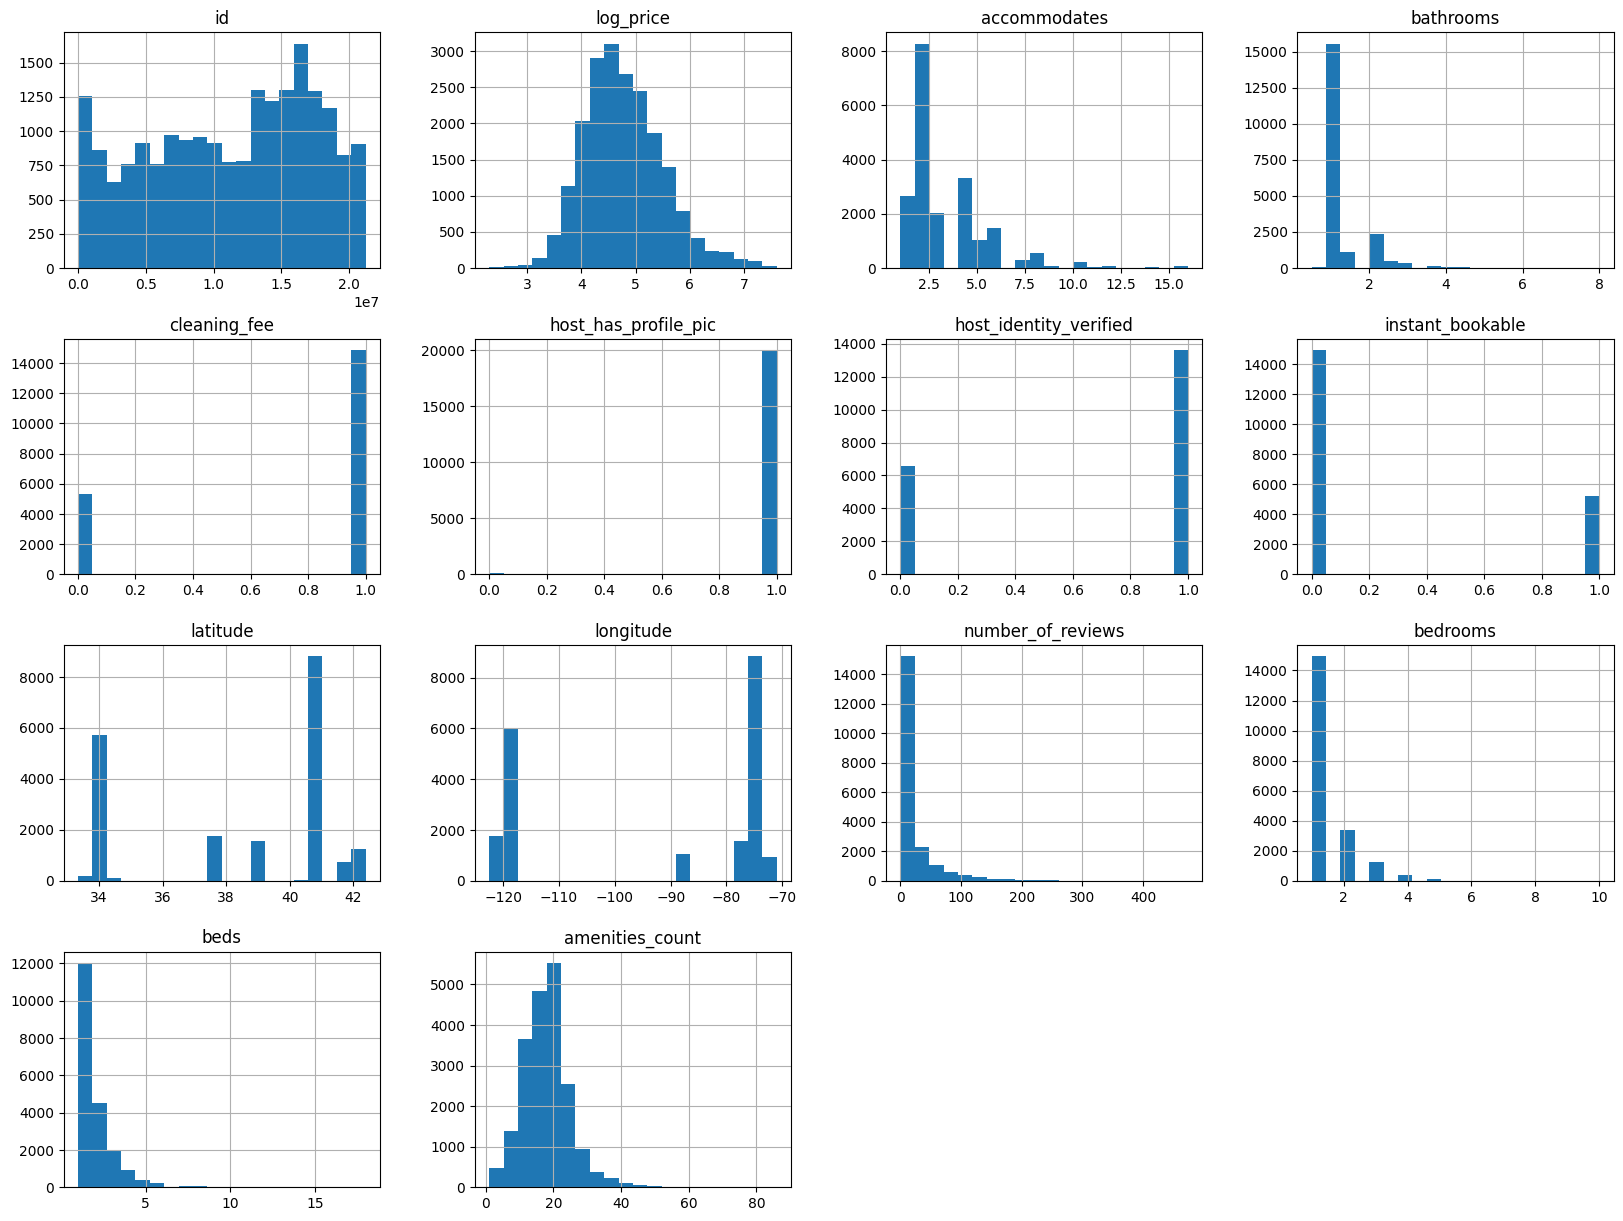

In [95]:
import matplotlib.pyplot as plt
df_train.hist(bins=20, figsize=(20, 15))
plt.show()
#Ce code utilise matplotlib pour afficher un histogramme de chaque colonne numérique du jeu de données df_train. 
#Cela permet de visualiser la distribution des variables (comme log_price, accommodates, bathrooms, etc.), d’identifier la présence d’outliers, 
#de détecter des asymétries ou des valeurs aberrantes, et de mieux comprendre l’échelle de chaque variable. 
#C’est une étape classique d’exploration pour adapter les traitements futurs comme la normalisation, la transformation logarithmique ou le choix d’un modèle adapté.

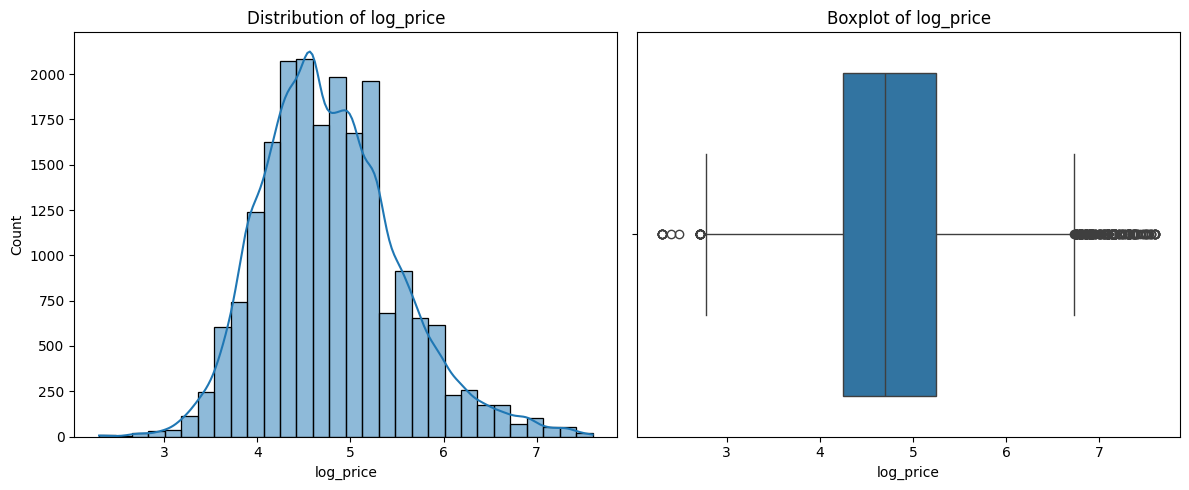

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Séparation des features et de la variable cible
X = df_train.drop(columns=['log_price'])
y = df_train['log_price']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of log_price")

plt.subplot(1, 2, 2)
sns.boxplot(x=y)
plt.title("Boxplot of log_price")

plt.tight_layout()
plt.show()

#Ce bloc de code sert à visualiser la distribution de la variable cible log_price, qui représente le logarithme du prix des logements. 
#Il utilise un histogramme avec estimation de densité pour observer la forme générale de la distribution, et une boîte à moustaches (boxplot) pour repérer d’éventuels outliers. 
#Cette double visualisation est très utile pour comprendre si la variable cible suit une loi normale, si elle contient des valeurs aberrantes, et donc pour décider d’éventuelles transformations ou traitements avant la modélisation.

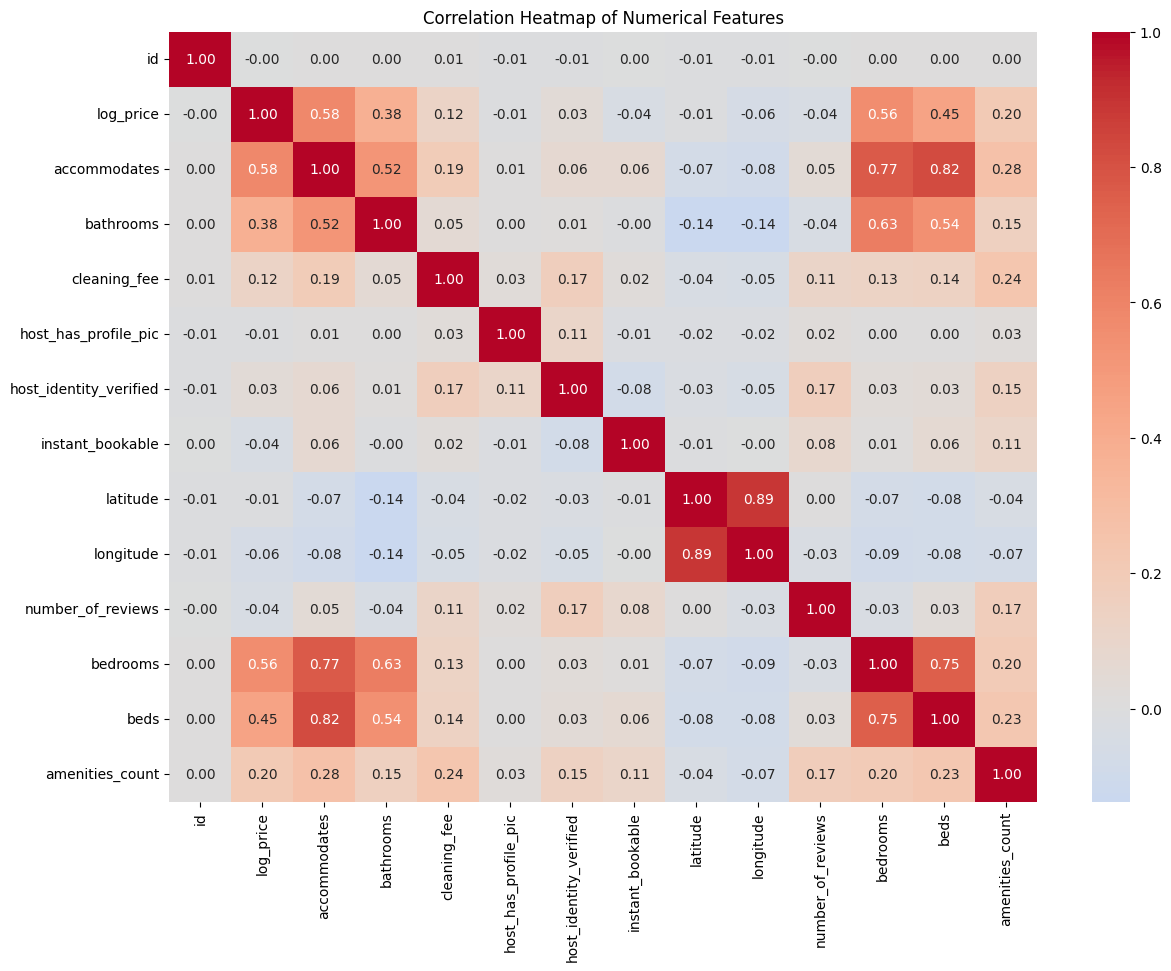

In [97]:
numeric_features = df_train.select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()
#Ce code permet d’analyser les relations linéaires entre les variables numériques du jeu de données df_train. 
#Il commence par extraire uniquement les colonnes numériques, puis calcule leur matrice de corrélation. Ensuite, 
#il affiche cette matrice sous forme de carte thermique (heatmap) avec seaborn, ce qui permet de visualiser rapidement quelles variables sont fortement corrélées entre elles et surtout avec la variable cible log_price. 
#Cela aide à détecter les redondances, ou les variables peu informatives pour la modélisation.

In [99]:
# Une méthode recommandée: encoder d'abord, puis entraîner le modèle
X = df_train.drop(columns='log_price')
y = df_train['log_price']

# Encodage des variables catégorielles(one-hot encoding)
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.astype(float)

# Séparation des données en ensemble d'entraînement et de validation(test set est 20%)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Entraînement du modèle de régression linéaire
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Prédiction
y_pred = model.predict(X_val)


In [100]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_val,y_pred)
r2 = r2_score(y_val, y_pred)
print(f"MSE= {np.sqrt(mse)}")
print(f"R^2= {r2}")

#mean_squared_error : calcule l’erreur quadratique moyenne (MSE). On en prend ici lanp.sqrt(mse)) pour obtenir la RMSE, quilog_price)；
#r2_score : calcule le coefficient de détermination R^2, qui mesure la part de variance de l
#Ces deux indicateurs permettent de juger si le modèle est précis.

MSE= 0.4689356368039506
R^2= 0.6018071962042643


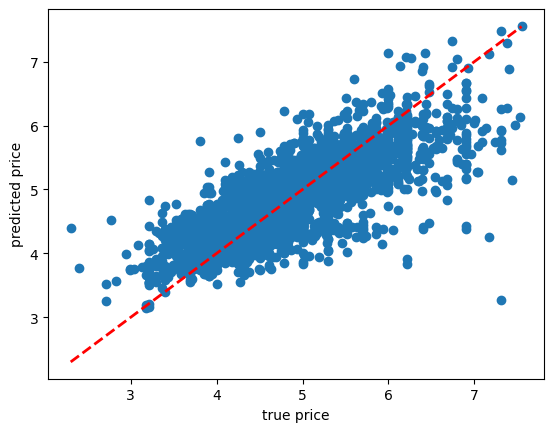

In [101]:
plt.scatter(y_val,y_pred)
plt.xlabel("true price")
plt.ylabel("predicted price")
plt.plot([y_val.min(),y_val.max()],[y_val.min(),y_val.max()],'r--',lw=2)
plt.show()
#Ce graphique en nuage de points (scatter plot) permet de visualiser la relation entre les valeurs réelles (y_val) et les valeurs prédites (y_pred) par le modèle sur l’ensemble de validation.
#Chaque point représente une prédiction pour un logement donné.
#Ligne rouge c’est la droite d’égalité parfaite, où la prédiction est exactement égale à la valeur réelle.
#Plus les points sont proches de cette ligne, meilleures sont les prédictions du modèle. 

In [102]:
#Predict test
df_test_encoded = pd.get_dummies(df_test, drop_first=True)
df_test_encoded = df_test_encoded.astype(float)

X_encoded, df_test_encoded = X_encoded.align(df_test_encoded, join='left', axis=1, fill_value=0)

predictions = model.predict(df_test_encoded)

output = pd.DataFrame({
    ' ': df_test['Unnamed: 0'],
    'logpred': predictions
})

output.to_csv('Han_WANG.csv', index=False)
print("test_pred_csv has exported")

test_pred_csv has exported
